# Fig 8 companion — 80-20 vs. 90-10 vs. 100-0 (three conditions)

**NEW figure for the 2026 reviewer response, built now that 90-10 sessions
exist** (`preprocessing/`'s new bhv2-conversion pipeline). This does **not**
modify Fig 8 itself (`fig8.py`, `Fig8.ipynb`, config.yaml's `fig8:` section) —
Fig 8 remains exactly the 80-20-vs-100-0 comparison it already was. This
notebook is a standalone companion covering the same panel layout (a–f) plus
one new panel (g, sticky Q-learning model parameters), generalized from two
conditions to three.

**Classifier:** the SAME `state_classifier.classify_state_v7` Fig 8 uses (not
Fig 9's simpler cross-species `classify_state_updated_noAdapting`) — this is
meant as a genuine subset/extension of Fig 8, not a repeat of Fig 9.

**Data source (disclosed design choice):** Fig 8 sources 80-20 and 100-0 from
two separate, dedicated snapshot CSVs, with the 100-0 side requiring a bespoke
pseudo-session split (`cross_condition.build_100_0_features_df`) for that
snapshot's own multi-block-per-raw-session quirk. Since 90-10 only exists in
the new merged master file
(`Merged_Data/preprocessed_master_merged_data_with_metadata_20260917.csv`),
this notebook sources **all three conditions from that one file**, reusing
`cross_species_comparison/run_pipeline_marmoset.py`'s already-validated
condition-generic feature construction (`load_and_prepare`/
`add_rolling_features`) rather than mixing two differently-built data
sources. Its `Block_Transition`/`Trials_Since_Transition` are computed
directly from `BlockCount` resets within the raw `Session_ID` — simpler than
Fig 8's own 100-0 pseudo-session split, not a claim that it's equivalent to
it. Flagged here plainly, per this project's standing convention, rather than
silently matched or ignored.

**Statistics:** Fig 8's paired t-tests only handle two groups. Here, a
Friedman test (non-parametric repeated-measures, matches this project's
per-animal-pseudoreplication-correction design) is used across the three
conditions instead. See `src/behavior_metrics/cross_condition_3way.py` for
every helper's exact generalization from `cross_condition.py`.

**Animals:** the same 5 Fig 8 overlapping animals (Fiona, Knuckles, Sonic,
Sunflower, Zazu) — confirmed to all have 90-10 sessions in the new merged
file too, so no animal drops out when the third condition is added.

**Panel f:** shown as two single-step diff heatmaps (80-20→90-10,
90-10→100-0) rather than one 80-20-vs-100-0 diff, so the gradient itself is
visible instead of collapsed to its two endpoints.

No threshold here is tuned to match any pre-existing printed value — there is
none; this is a new figure.

In [1]:
import os
import sys
import json

import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath(".."))

from src.io.load_snapshots import load_config
from src.behavior_metrics import (
    cross_condition, cross_condition_3way as cc3, state_taxonomy_v7 as sx7,
    reversal_alignment as ra, q_following_model,
)
from src.plotting.style import apply_style
from src.plotting import fig8_3cond as plotting

config = load_config()
apply_style(config)
cfg = config["fig8_3cond"]
ANIMAL_COLORS = config["plotting"]["animal_colors"]
ANIMAL_ORDER = config["plotting"]["animal_order"]
st_cfg = config["state_taxonomy"]
CONDITIONS = cfg["conditions"]
ANIMALS = cfg["overlapping_animals"]

FIG_DIR = os.path.join("..", config["paths"]["figures_out"], "Fig8_3cond")
os.makedirs(FIG_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {"_stage": "Fig 8 companion -- 80-20 vs 90-10 vs 100-0, classify_state_v7",
            "conditions": CONDITIONS, "animals": ANIMALS}

## Data loading & classification
Builds the classify_state_v7-ready feature dataframe for each condition from
the new merged master file, then classifies with the same classifier Fig 8
uses (see `cross_condition_3way.load_and_classify_3way`).

In [2]:
CROSS_SPECIES_DIR = os.path.normpath(os.path.join(os.path.abspath(".."), cfg["cross_species_dir"]))
dfs, block_labels = cc3.load_and_classify_3way(
    cfg.get("master_input_file"), CROSS_SPECIES_DIR, CONDITIONS, ANIMALS, st_cfg
)

for c in CONDITIONS:
    d = dfs[c]
    print(f"{c}: {len(d):,} trials, {d['Session_ID'].nunique()} sessions, "
          f"{d['Animal_Name'].nunique()} animals, {len(block_labels[c])} block transitions")
    manifest[f"n_trials_{c.replace('-', '_')}"] = int(len(d))
    manifest[f"n_sessions_{c.replace('-', '_')}"] = int(d["Session_ID"].nunique())

80-20: 62,827 trials, 187 sessions, 5 animals, 3041 block transitions
90-10: 26,540 trials, 105 sessions, 5 animals, 1273 block transitions
100-0: 31,216 trials, 103 sessions, 5 animals, 1482 block transitions


## Behavioral-state distributions
All three conditions, same classifier, for a direct like-for-like comparison.

In [3]:
for c in CONDITIONS:
    d = dfs[c]
    counts = d["Behavioral_State"].value_counts()
    pct = (counts / len(d) * 100).round(2)
    print(f"\nState distribution ({c}):")
    for state, count in counts.items():
        print(f"  {state:25s}: {count:5d} ({pct[state]:.2f}%)")
    manifest[f"state_distribution_{c.replace('-', '_')}"] = {
        state: {"n": int(count), "pct": float(pct[state])} for state, count in counts.items()
    }


State distribution (80-20):
  Exploit                  : 23847 (37.96%)
  Directed Exploration     : 14786 (23.53%)
  Adapting (fast)          :  8030 (12.78%)
  Adapting (slow)          :  7094 (11.29%)
  Left Bias                :  2965 (4.72%)
  Right Bias               :  2963 (4.72%)
  Random Exploration       :  2768 (4.41%)
  Unknown                  :   374 (0.60%)

State distribution (90-10):
  Exploit                  : 12121 (45.67%)
  Directed Exploration     :  3660 (13.79%)
  Adapting (fast)          :  3248 (12.24%)
  Adapting (slow)          :  3046 (11.48%)
  Right Bias               :  2058 (7.75%)
  Left Bias                :  2027 (7.64%)
  Unknown                  :   210 (0.79%)
  Random Exploration       :   170 (0.64%)

State distribution (100-0):
  Exploit                  : 17586 (56.34%)
  Adapting (fast)          :  4473 (14.33%)
  Directed Exploration     :  2909 (9.32%)
  Adapting (slow)          :  2892 (9.26%)
  Left Bias                :  1607 (5.15%)


## Panel a
p(high-prob choice) aligned to block reversal, 80-20 / 90-10 / 100-0 (left);
paired per-animal mean session accuracy across all three conditions (right).
Friedman test across the 5 shared animals.

Pseudoreplication correction: aligned curves are averaged per-animal first,
then across animals -- same convention as Fig 8 panel a.

Mean session accuracy, 80-20 vs 90-10 vs 100-0 (Friedman, n=5): chi2=10.000, p=0.006738


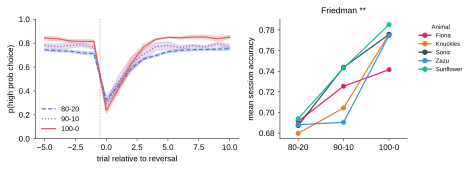

In [4]:
def _per_animal_position_summary(df, blabels, value_col):
    trans = blabels.rename(columns={"Session_ID": "session_id", "BlockCount": "to_block", "Animal_Name": "animal"})
    aligned = ra.accuracy_by_position_relative_to_transition(
        df, trans, value_col, cfg["reversal_alignment_pre"], cfg["reversal_alignment_post"], block_col="BlockCount"
    )
    per_animal = aligned.groupby(["position", "animal"])["accuracy"].mean().reset_index()
    summary = per_animal.groupby("position")["accuracy"].agg(
        mean="mean", sem=lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan, n="count"
    ).reset_index()
    return per_animal, summary

pos_animal_acc, pos_summary_acc = {}, {}
for c in CONDITIONS:
    pos_animal_acc[c], pos_summary_acc[c] = _per_animal_position_summary(dfs[c], block_labels[c], "High_Prob")

animal_acc_by_condition = {c: dfs[c].groupby("Animal_Name")["High_Prob"].mean().to_dict() for c in CONDITIONS}
acc_comparison = cc3.friedman_paired_comparison(animal_acc_by_condition, ANIMALS, CONDITIONS)
print(f"Mean session accuracy, {' vs '.join(CONDITIONS)} (Friedman, n={acc_comparison['n']}): "
      f"chi2={acc_comparison['chi2']:.3f}, p={acc_comparison['p']:.4g}")
manifest["panel_a_accuracy_comparison"] = {
    k: (v.tolist() if isinstance(v, np.ndarray) else v) for k, v in acc_comparison.items()
}

from IPython.display import SVG, display

out_a = os.path.join(FIG_DIR, "Fig8_3cond_a_reversal_aligned_accuracy.svg")
plotting.plot_panel_a(pos_summary_acc, acc_comparison, CONDITIONS, ANIMAL_COLORS, ANIMAL_ORDER, out_a)
display(SVG(out_a))

## Panel b
Mean p(switch) aligned to block reversal, all three conditions.

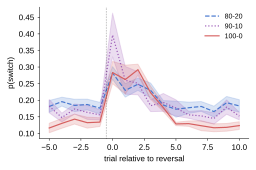

In [5]:
pos_animal_switch, pos_summary_switch = {}, {}
for c in CONDITIONS:
    pos_animal_switch[c], pos_summary_switch[c] = _per_animal_position_summary(dfs[c], block_labels[c], "PhysicalSwitch")

out_b = os.path.join(FIG_DIR, "Fig8_3cond_b_reversal_aligned_switch.svg")
plotting.plot_panel_b(pos_summary_switch, CONDITIONS, out_b)
display(SVG(out_b))

## Panel c
Proportion of trials spent in each behavioral state (excluding Adapting),
80-20 / 90-10 / 100-0. Friedman test per state across the 5 shared animals.

Exploit               : 80-20=0.512  90-10=0.600  100-0=0.740  chi2=10.000  p=0.006738
Directed Exploration  : 80-20=0.302  90-10=0.195  100-0=0.123  chi2=10.000  p=0.006738
Random Exploration    : 80-20=0.058  90-10=0.009  100-0=0.001  chi2=10.000  p=0.006738
Left Bias             : 80-20=0.069  90-10=0.097  100-0=0.069  chi2=1.200  p=0.5488
Right Bias            : 80-20=0.059  90-10=0.100  100-0=0.068  chi2=7.600  p=0.02237


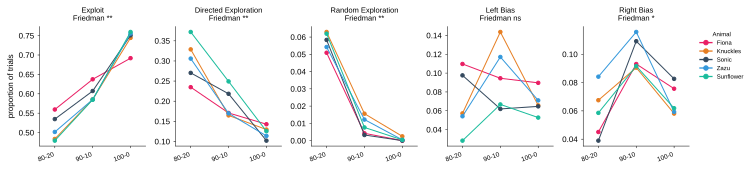

In [6]:
proportions_result = cc3.compare_state_proportions_nway(dfs, cfg["states_full"], ANIMALS, CONDITIONS)
for state, r in proportions_result.items():
    means = {c: float(np.nanmean(r[f"values_{c.replace('-', '_')}"])) for c in CONDITIONS}
    print(f"{state:22s}: " + "  ".join(f"{c}={means[c]:.3f}" for c in CONDITIONS) +
          f"  chi2={r['chi2']:.3f}  p={r['p']:.4g}")
manifest["panel_c_state_proportions"] = {
    state: {k: (v.tolist() if isinstance(v, np.ndarray) else v) for k, v in r.items()}
    for state, r in proportions_result.items()
}

out_c = os.path.join(FIG_DIR, "Fig8_3cond_c_state_proportions.svg")
plotting.plot_panel_c(proportions_result, cfg["states_full"], CONDITIONS, ANIMAL_COLORS, ANIMAL_ORDER, out_c)
display(SVG(out_c))

## Panel d
Win-stay (left) and lose-switch (right) probabilities for Exploitation and
Directed Exploration, all three conditions. Friedman test per state/metric.

win_stay     Exploit               : 80-20=0.949  90-10=0.947  100-0=0.938  chi2=0.400  p=0.8187
win_stay     Directed Exploration  : 80-20=0.756  90-10=0.722  100-0=0.843  chi2=10.000  p=0.006738
lose_switch  Exploit               : 80-20=0.074  90-10=0.115  100-0=0.323  chi2=10.000  p=0.006738
lose_switch  Directed Exploration  : 80-20=0.397  90-10=0.425  100-0=0.449  chi2=2.800  p=0.2466


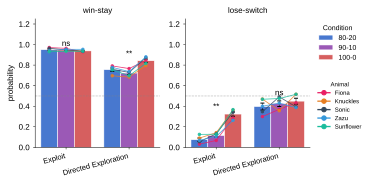

In [7]:
wsls_result = cc3.compare_win_stay_lose_switch_nway(dfs, cfg["wsls_states"], ANIMALS, CONDITIONS)
for metric in ("win_stay", "lose_switch"):
    for state, r in wsls_result[metric].items():
        means = {c: float(np.nanmean(r[f"values_{c.replace('-', '_')}"])) for c in CONDITIONS}
        print(f"{metric:12s} {state:22s}: " + "  ".join(f"{c}={means[c]:.3f}" for c in CONDITIONS) +
              f"  chi2={r['chi2']:.3f}  p={r['p']:.4g}")
manifest["panel_d_win_stay_lose_switch"] = {
    metric: {
        state: {k: (v.tolist() if isinstance(v, np.ndarray) else v) for k, v in r.items()}
        for state, r in wsls_result[metric].items()
    }
    for metric in ("win_stay", "lose_switch")
}

out_d = os.path.join(FIG_DIR, "Fig8_3cond_d_win_stay_lose_switch.svg")
plotting.plot_panel_d(wsls_result, cfg["wsls_states"], CONDITIONS, ANIMAL_COLORS, ANIMAL_ORDER, out_d)
display(SVG(out_d))

## Panel e
p(switch) as a function of consecutive losses within Exploitation, all three
conditions.

**Correction (found while investigating a real discrepancy with the
published Fig 8 panel e):** `cross_condition.switch_vs_consecutive_losses`
(the function Fig 8 itself uses) does not reproduce the published figure --
it computes the loss streak over ALL trials (resetting on leaving the
state) and checks the NEXT chronological trial's switch, rather than the
source notebook's own method (`09b_CrossProb_StickyModel_v1.ipynb` cell 38):
filter to `Behavioral_State == "Exploit"` FIRST, count the streak within
that filtered subsequence, and check the filtered row's OWN switch. Verified
directly against Fig 8's own real reconstructed data: the source's method
reproduces the published 100-0 jump (p(switch) 0.060 -> 0.387 at streak 1),
where `cross_condition.switch_vs_consecutive_losses` gives 0.081 -> 0.128
(ns) on the same data. This notebook uses the corrected
`cross_condition_3way.switch_vs_consecutive_losses_source_algorithm`
instead -- see that function's docstring. `cross_condition.py` itself
(and Fig 8's own notebook) are left untouched pending the user's decision
on whether to fix the shared function there too.


80-20:
  Loss_Streak     mean      sem  n
           0 0.051961 0.007828  5
           1 0.078545 0.017614  5
           2 0.039272 0.009164  5
           3 0.066667 0.066667  5
           4 0.000000 0.000000  2

90-10:
  Loss_Streak     mean      sem  n
           0 0.053525 0.005300  5
           1 0.117625 0.013941  5
           2 0.038571 0.027811  5
           3 0.000000      NaN  1

100-0:
  Loss_Streak     mean      sem  n
           0 0.062890 0.004140  5
           1 0.322275 0.020619  5
           2 0.444444 0.293972  3

Friedman test per loss-streak length (Exploit state):
  streak=0: chi2=0.400  p=0.8187  n=5
  streak=1: chi2=8.400  p=0.015  n=5
  streak=2: chi2=1.636  p=0.4412  n=3


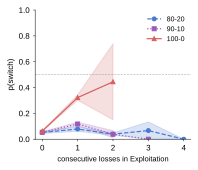

In [8]:
streak_summary, streak_comparison = cc3.compare_loss_streak_nway(
    dfs, "Exploit", ANIMALS, CONDITIONS, cfg["max_consecutive_losses"]
)
for c in CONDITIONS:
    print(f"\n{c}:\n", streak_summary[c].to_string(index=False))
print("\nFriedman test per loss-streak length (Exploit state):")
for streak, r in streak_comparison.items():
    print(f"  streak={streak}: chi2={r['chi2']:.3f}  p={r['p']:.4g}  n={r['n']}")
manifest["panel_e_switch_vs_streak"] = {
    c.replace("-", "_"): streak_summary[c].to_dict(orient="records") for c in CONDITIONS
}
manifest["panel_e_friedman_by_streak"] = {
    str(streak): {k: (v.tolist() if isinstance(v, np.ndarray) else v) for k, v in r.items()}
    for streak, r in streak_comparison.items()
}

out_e = os.path.join(FIG_DIR, "Fig8_3cond_e_switch_vs_consecutive_losses.svg")
plotting.plot_panel_e(streak_summary, CONDITIONS, out_e)
display(SVG(out_e))

## Panel f
Change in trial-to-trial state-transition probability, restricted to
Exploitation<->Directed Exploration, walked in two single steps
(80-20→90-10, 90-10→100-0) rather than one 80-20-vs-100-0 diff.

Transition-probability table: 350 (condition, animal, from_state, to_state) rows

80-20 -> 90-10 (Exploitation <-> Directed Exploration):
  Exploit -> Exploit: diff=+0.018  p=0.1019
  Exploit -> Directed Exploration: diff=-0.022  p=0.1031
  Directed Exploration -> Exploit: diff=+0.072  p=0.005418
  Directed Exploration -> Directed Exploration: diff=-0.087  p=0.02377

90-10 -> 100-0 (Exploitation <-> Directed Exploration):
  Exploit -> Exploit: diff=+0.037  p=0.006941
  Exploit -> Directed Exploration: diff=-0.024  p=0.05026
  Directed Exploration -> Exploit: diff=+0.088  p=0.02113
  Directed Exploration -> Directed Exploration: diff=-0.147  p=0.01338


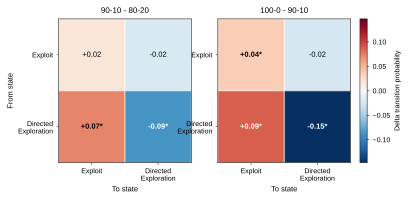

In [9]:
trans_df = cc3.compute_transition_probabilities_nway(
    dfs, cfg["states_full"], ANIMALS, cfg["min_trials_per_transition"], CONDITIONS
)
print(f"Transition-probability table: {len(trans_df)} (condition, animal, from_state, to_state) rows")

diff_ab = cc3.compute_diff_matrix_pair(trans_df, cfg["states_key_main"], ANIMALS, "80-20", "90-10")
diff_bc = cc3.compute_diff_matrix_pair(trans_df, cfg["states_key_main"], ANIMALS, "90-10", "100-0")

for label, diff in (("80-20 -> 90-10", diff_ab), ("90-10 -> 100-0", diff_bc)):
    print(f"\n{label} (Exploitation <-> Directed Exploration):")
    for i, fs in enumerate(diff["states"]):
        for j, ts in enumerate(diff["states"]):
            print(f"  {fs} -> {ts}: diff={diff['diff_matrix'][i, j]:+.3f}  p={diff['pval_matrix'][i, j]:.4g}")

manifest["panel_f_diff_80_20_to_90_10"] = {
    "states": diff_ab["states"], "diff_matrix": diff_ab["diff_matrix"].tolist(),
    "pval_matrix": diff_ab["pval_matrix"].tolist(),
}
manifest["panel_f_diff_90_10_to_100_0"] = {
    "states": diff_bc["states"], "diff_matrix": diff_bc["diff_matrix"].tolist(),
    "pval_matrix": diff_bc["pval_matrix"].tolist(),
}

out_f = os.path.join(FIG_DIR, "Fig8_3cond_f_transition_probability_change.svg")
plotting.plot_panel_f(diff_ab, diff_bc, out_f)
display(SVG(out_f))

## Panel g — sticky Q-learning model (new)
Not part of Fig 8's own panel a-f (state classification doesn't use
Q-values); included as an additional panel per user request, mirroring Fig
9 panel b but restricted to marmoset and this figure's three conditions,
using Fig 8/Supp Fig 3's own `q_following_model.fit_sticky_qlearning`
(single-init fit, same bounds) rather than the cross-species 10-restart
version.

Sticky Q-learning params, 80-20 vs 90-10 vs 100-0 (Friedman across shared animals):
  alpha: 80-20=0.728  90-10=0.703  100-0=0.791  chi2=3.600  p=0.1653
  beta: 80-20=1.046  90-10=1.335  100-0=0.783  chi2=0.400  p=0.8187
  kappa: 80-20=1.307  90-10=1.444  100-0=1.475  chi2=1.200  p=0.5488


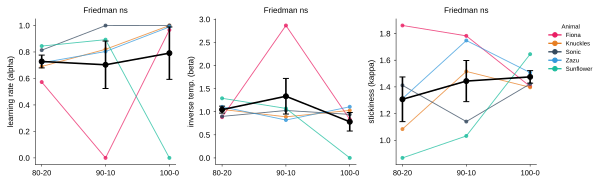

In [10]:
sticky_x0 = config["suppfig3"]["sticky_model_x0"]
sticky_bounds = config["suppfig3"]["sticky_model_bounds"]
sticky_result = cc3.fit_sticky_nway(dfs, sticky_x0, sticky_bounds, q_following_model.fit_sticky_qlearning, ANIMALS, CONDITIONS)

print(f"Sticky Q-learning params, {' vs '.join(CONDITIONS)} (Friedman across shared animals):")
for param, r in sticky_result["comparison"].items():
    means = {c: float(np.nanmean(r[f"values_{c.replace('-', '_')}"])) for c in CONDITIONS}
    print(f"  {param}: " + "  ".join(f"{c}={means[c]:.3f}" for c in CONDITIONS) +
          f"  chi2={r['chi2']:.3f}  p={r['p']:.4g}")
manifest["panel_g_sticky_qlearning_comparison"] = {
    param: {k: (v.tolist() if isinstance(v, np.ndarray) else v) for k, v in r.items()}
    for param, r in sticky_result["comparison"].items()
}

out_g = os.path.join(FIG_DIR, "Fig8_3cond_g_sticky_model_params.svg")
plotting.plot_panel_g_sticky_model(sticky_result["comparison"], CONDITIONS, ANIMAL_COLORS, ANIMAL_ORDER, out_g)
display(SVG(out_g))

## Values manifest

In [11]:
manifest_path = os.path.join(MANIFEST_DIR, "Fig8_3cond.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\nSaved values manifest: {manifest_path}")


Saved values manifest: ../outputs/values_manifests/Fig8_3cond.json
